# L3AC Codec Inference Test

This notebook demonstrates how to:
1. Load a trained L3AC codec model
2. Load an input audio file
3. Encode audio (encoder + quantization)
4. Decode audio (decoder)
5. Save and play the reconstructed audio

## 1. Import Libraries

In [1]:
%xmode Plain

Exception reporting mode: Plain


In [2]:
import os
import sys
import torch
import numpy as np
import librosa
import soundfile as sf
from pathlib import Path
from IPython.display import Audio, display
import matplotlib.pyplot as plt

# Add L3AC source to path
sys.path.insert(0, str(Path.cwd() / 'src'))

import l3ac

print("✅ Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Output()

✅ Libraries imported successfully

PyTorch version: 2.7.1+cu118

/opt/conda/envs/l3ac/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: 
CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable 
CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at 
/pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0

CUDA available: False

In [3]:
l3ac.list_models()

['3kbps_debug',
 'ablation',
 '1kbps',
 '3kbps',
 '3kbps_music',
 '1k5bps',
 '3kbps_music_infer',
 '0k75bps']

## 2. Load the Trained Model

In [4]:
# Set device to CPU first (before loading model)
device = "cpu"
torch.cuda.is_available = lambda: False  # Disable CUDA detection

# Load model using l3ac.get_model()
config_name = '3kbps_music_infer'  # Config file name (without .toml)
model = l3ac.get_model(config_name)
print(f"✅ Model loaded successfully")
print(f"Sample rate: {model.config.sample_rate}")
print(f"Model version: {model.config.model_version}")
print(f"Model info: {l3ac.get_model_info(model.network)}")

DEBUG: Looking for config at: /workspace/codec/L3AC/src/model/exp/configs/3kbps_music_infer.toml

DEBUG: Does file exist? True

✅ Model loaded successfully

Sample rate: 16000

Model version: v1

Model info: {'macs': '1.64 GMac', 'params': '10.28 M', 'codebook_size': 250047, 'frame_rate': 166.66666666666666, 
'bps': 2988.6399617499583, 'receptive_field': 2.4000000000000004}

In [ ]:
# Ensure model is on CPU and in eval mode
model.network.to(device)
model.network.eval()

print(f"✅ Model ready for inference on {device}")

✅ Model ready for inference on cpu

In [6]:
# Load pretrained weights from checkpoint directory
model_dir = Path("/workspace/codec/L3AC/output/best_model/l3ac.en_codec.EnCodec")

print(f"Loading weights from: {model_dir}")
print(f"Available files: {list(model_dir.glob('*.pt'))}")

# Load each module's weights
weight_modules = ['encoder', 'decoder', 'quantizer', 'en_encoder', 'en_decoder']

for module_name in weight_modules:
    weight_path = model_dir / f"{module_name}.pt"
    if weight_path.exists():
        state_dict = torch.load(weight_path, map_location=device)
        getattr(model.network, module_name).load_state_dict(state_dict, strict=False)
        print(f"✅ Loaded {module_name}")
    else:
        print(f"⚠️ Warning: {module_name}.pt not found")

print(f"✅ All weights loaded successfully")

Loading weights from: /workspace/codec/L3AC/output/best_model/l3ac.en_codec.EnCodec

Available files: [PosixPath('/workspace/codec/L3AC/output/best_model/l3ac.en_codec.EnCodec/en_decoder.pt'), 
PosixPath('/workspace/codec/L3AC/output/best_model/l3ac.en_codec.EnCodec/en_encoder.pt'), 
PosixPath('/workspace/codec/L3AC/output/best_model/l3ac.en_codec.EnCodec/encoder.pt'), 
PosixPath('/workspace/codec/L3AC/output/best_model/l3ac.en_codec.EnCodec/decoder.pt'), 
PosixPath('/workspace/codec/L3AC/output/best_model/l3ac.en_codec.EnCodec/quantizer.pt')]

✅ Loaded encoder

✅ Loaded decoder

✅ Loaded quantizer

✅ Loaded en_encoder

✅ Loaded en_decoder

✅ All weights loaded successfully

## 3. Load Input Audio

**Note:** Replace the audio path below with your own audio file path

In [ ]:
# ⚠️ CHANGE THIS PATH to your audio file
LOCAL_AUDIO_PATH = "/workspace/codec/L3AC/data/assets/input_audio_0.wav"

# Alternative: use librosa example audio
USE_EXAMPLE_AUDIO = True  # Set to False to use your own audio

if USE_EXAMPLE_AUDIO:
    print("Loading librosa example audio...")
    audio_data, sr = librosa.load(librosa.example("libri1"), sr=None)
else:
    print(f"Loading audio from: {LOCAL_AUDIO_PATH}")
    audio_data, sr = librosa.load(LOCAL_AUDIO_PATH, sr=None)

print(f"Original audio shape: {audio_data.shape}")
print(f"Original sample rate: {sr} Hz")
print(f"Duration: {len(audio_data) / sr:.2f} seconds")

# Resample to model's sample rate if needed
target_sr = model.config.sample_rate
if sr != target_sr:
    print(f"Resampling from {sr} Hz to {target_sr} Hz...")
    audio_data = librosa.resample(audio_data, orig_sr=sr, target_sr=target_sr)
    sr = target_sr

# Prepare for model input: (batch, samples)
audio_input = audio_data[None, :]
print(f" Processed audio shape: {audio_input.shape}")

# Play original audio
print(" 🔊 Original Audio:")
display(Audio(audio_data, rate=sr))

Loading librosa example audio...

Original audio shape: (327222,)

Original sample rate: 22050 Hz

Duration: 14.84 seconds

Resampling from 22050 Hz to 16000 Hz...

Processed audio shape: (1, 237440)

🔊 Original Audio:

## 4. Visualize Original Audio

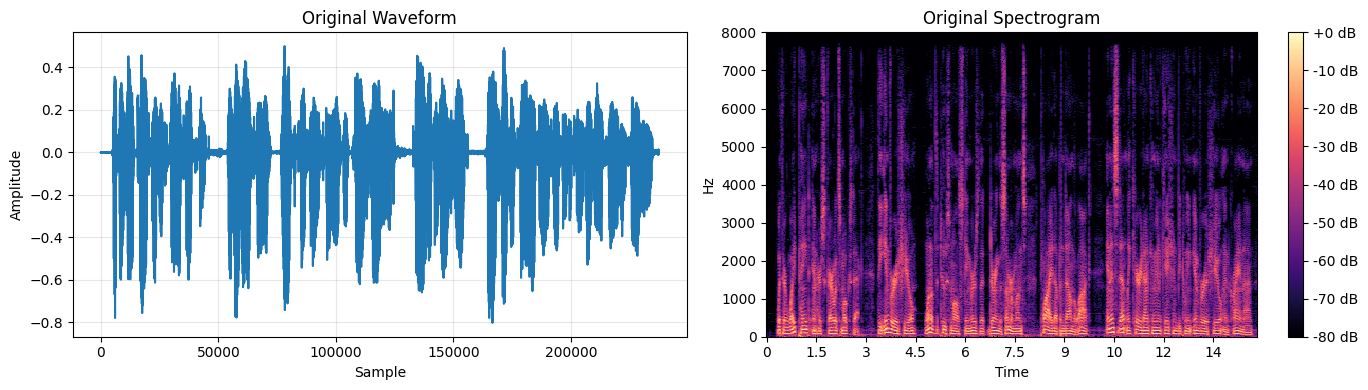

In [ ]:
# Plot waveform
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(audio_data)
plt.title("Original Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Plot spectrogram
plt.subplot(1, 2, 2)
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_data)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Original Spectrogram")
plt.tight_layout()
plt.show()

## 5. Encode Audio (Encoder + Quantization)

In [9]:
# Convert to torch tensor
audio_tensor = torch.tensor(audio_input, dtype=torch.float32, device=device)
print(f"Input tensor shape: {audio_tensor.shape}")

# Run encoding using model.encode_audio()
with torch.inference_mode():
    q_feature, indices = model.encode_audio(audio_tensor)
    print(f"✅ Encoding successful")
    print(f"Quantized feature shape: {q_feature.shape}")
    print(f"Indices type: {type(indices)}")

Input tensor shape: torch.Size([1, 237440])

✅ Encoding successful

Quantized feature shape: torch.Size([1, 2474, 128])

Indices type: <class 'dict'>

## 6. Decode Audio (Decoder)

In [ ]:
# Run decoding using model.decode_audio()
with torch.inference_mode():
    audio_reconstructed = model.decode_audio(q_feature)
    print(f"✅ Decoding successful")
    print(f"Reconstructed audio shape: {audio_reconstructed.shape}")

# Trim to original length
audio_length = audio_input.shape[-1]
audio_reconstructed = audio_reconstructed[:, :audio_length]

# Convert to numpy
reconstructed_numpy = audio_reconstructed.detach().cpu().numpy().squeeze()
print(f"Final reconstructed shape: {reconstructed_numpy.shape}")

✅ Decoding successful

Reconstructed audio shape: torch.Size([1, 237504])

Final reconstructed shape: (237440,)

## 7. Evaluate Reconstruction Quality

In [11]:
# Calculate MSE
mse = np.mean((audio_data - reconstructed_numpy) ** 2)
print(f"Mean Squared Error (MSE): {mse:.6f}")

# Calculate SNR
signal_power = np.mean(audio_data ** 2)
noise_power = np.mean((audio_data - reconstructed_numpy) ** 2)
snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')
print(f"Signal-to-Noise Ratio (SNR): {snr:.2f} dB")

# Try to calculate PESQ and STOI if available
try:
    from pesq import pesq
    pesq_score = pesq(sr, audio_data, reconstructed_numpy, 'wb')
    print(f"PESQ Score: {pesq_score:.3f}")
except ImportError:
    print("⚠️ PESQ not available (install with: pip install pesq)")

try:
    from pystoi import stoi
    stoi_score = stoi(audio_data, reconstructed_numpy, sr, extended=False)
    print(f"STOI Score: {stoi_score:.3f}")
except ImportError:
    print("⚠️ STOI not available (install with: pip install pystoi)")

Mean Squared Error (MSE): 0.007021

Signal-to-Noise Ratio (SNR): 2.53 dB

STOI Score: 0.781

## 8. Visualize Reconstructed Audio

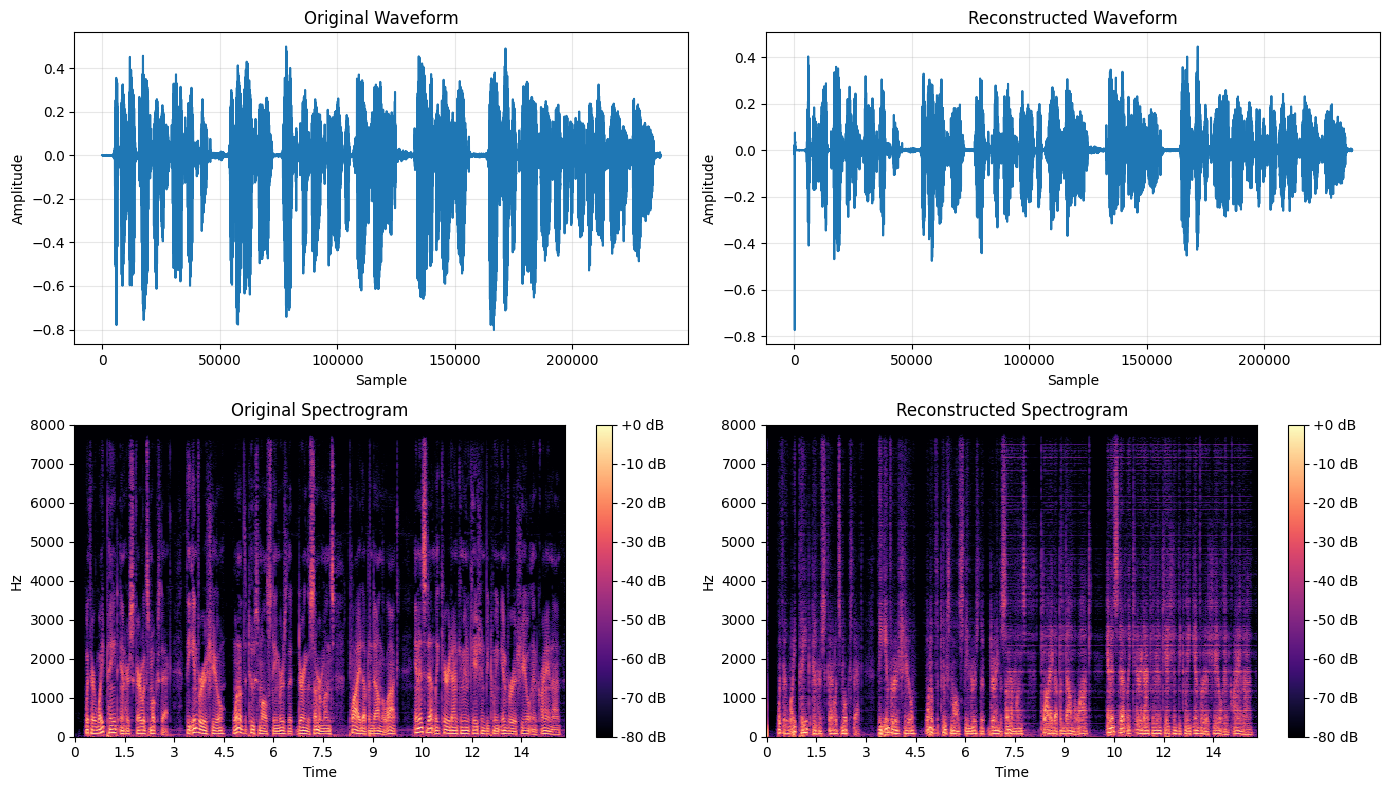

In [ ]:
# Plot comparison
plt.figure(figsize=(14, 8))

# Original waveform
plt.subplot(2, 2, 1)
plt.plot(audio_data)
plt.title("Original Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Reconstructed waveform
plt.subplot(2, 2, 2)
plt.plot(reconstructed_numpy)
plt.title("Reconstructed Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Original spectrogram
plt.subplot(2, 2, 3)
D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(audio_data)), ref=np.max)
librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Original Spectrogram")

# Reconstructed spectrogram
plt.subplot(2, 2, 4)
D_recon = librosa.amplitude_to_db(np.abs(librosa.stft(reconstructed_numpy)), ref=np.max)
librosa.display.specshow(D_recon, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Reconstructed Spectrogram")

plt.tight_layout()
plt.show()

## 9. Play Reconstructed Audio

In [ ]:
# Play reconstructed audio
print("🔊 Reconstructed Audio:")
display(Audio(reconstructed_numpy, rate=sr))

print(" 🔊 Original Audio (for comparison):")
display(Audio(audio_data, rate=sr))

🔊 Reconstructed Audio:

🔊 Original Audio (for comparison):

## 10. Save Reconstructed Audio

In [14]:
# Create output directory
output_dir = Path("/workspace/codec/L3AC/output/inference_results")
output_dir.mkdir(parents=True, exist_ok=True)

# Save original audio
original_path = output_dir / "original_audio.wav"
sf.write(original_path, audio_data, sr)
print(f"✅ Saved original audio to: {original_path}")

# Save reconstructed audio
reconstructed_path = output_dir / "reconstructed_audio.wav"
sf.write(reconstructed_path, reconstructed_numpy, sr)
print(f"✅ Saved reconstructed audio to: {reconstructed_path}")

print(f"✅ All outputs saved to: {output_dir}")

✅ Saved original audio to: /workspace/codec/L3AC/output/inference_results/original_audio.wav

✅ Saved reconstructed audio to: /workspace/codec/L3AC/output/inference_results/reconstructed_audio.wav

✅ All outputs saved to: /workspace/codec/L3AC/output/inference_results

## 11. Summary

In [ ]:
print("="*60)
print("L3AC Codec Inference Summary")
print("="*60)
print(f"Model Config: {config_name}")
print(f"Sample Rate: {sr} Hz")
print(f"Audio Duration: {len(audio_data) / sr:.2f} seconds")
print(f"Input Shape: {audio_input.shape}")
print(f"Quantized Feature Shape: {q_feature.shape}")
print(f"Output Shape: {reconstructed_numpy.shape}")
print(f" Quality Metrics:")
print(f"  - MSE: {mse:.6f}")
print(f"  - SNR: {snr:.2f} dB")
print(f" Output Files:")
print(f"  - Original: {original_path}")
print(f"  - Reconstructed: {reconstructed_path}")
print("="*60)

============================================================

L3AC Codec Inference Summary

============================================================

Model Config: 3kbps_music_infer

Sample Rate: 16000 Hz

...

- SNR: 2.53 dB

Output Files:

- Original: /workspace/codec/L3AC/output/inference_results/original_audio.wav

- Reconstructed: /workspace/codec/L3AC/output/inference_results/reconstructed_audio.wav

============================================================